# 02 · So sánh 6 hàm mất mát

Yêu cầu bắt buộc của đề bài. Kiến trúc giữ **cố định** (`transpose` +
`full skip`), chỉ đổi đúng một biến là hàm mất mát.

Sáu lượt chạy, mỗi lượt 20–30 phút trên T4. Nên chia hai tài khoản Colab:
tài khoản 1 chạy `bce`, `weighted_bce`, `dice`; tài khoản 2 chạy `bce_dice`,
`focal`, `tversky`. Cuối cùng gộp hai file `logs/runs.csv` lại.

Người phụ trách: **SV A** chạy, **SV B** tổng hợp.

In [1]:
# Chạy được cả trên Colab lẫn máy cá nhân
import sys, os
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB and not Path("unet-kvasir").exists():
    # !git clone <repo cua nhom> unet-kvasir
    pass
ROOT = Path("unet-kvasir") if Path("unet-kvasir").exists() else Path("..")
os.chdir(ROOT.resolve())
sys.path.insert(0, str(Path.cwd()))

%load_ext autoreload
%autoreload 2

from src import *
print("Thư mục làm việc:", Path.cwd())
print("Thiết bị:", get_device())

Thư mục làm việc: /root/workspace/unet-kvasir
Thiết bị: cuda


In [2]:
base = Config(up_mode="transpose", skip_mode="full", epochs=120, seed=42)

# Đổi lát cắt này khi chia việc giữa hai tài khoản Colab
MY_LOSSES = LOSS_NAMES            # hoặc LOSS_NAMES[:3] / LOSS_NAMES[3:]
configs = [base.replace(loss_name=name, tag="loss_sweep") for name in MY_LOSSES]

for c in configs:
    print(c.run_id)

bce-transpose-full-s42-19d844
weighted_bce-transpose-full-s42-daf02a
dice-transpose-full-s42-011006
bce_dice-transpose-full-s42-c6245d
focal-transpose-full-s42-83feaf
tversky-transpose-full-s42-8678ba


In [3]:
results = run_sweep(configs)


----- [1/6] -----
[bỏ qua] bce-transpose-full-s42-19d844 đã có trong log.

----- [2/6] -----
[bỏ qua] weighted_bce-transpose-full-s42-daf02a đã có trong log.

----- [3/6] -----
[bỏ qua] dice-transpose-full-s42-011006 đã có trong log.

----- [4/6] -----
[bỏ qua] bce_dice-transpose-full-s42-c6245d đã có trong log.

----- [5/6] -----
[bỏ qua] focal-transpose-full-s42-83feaf đã có trong log.

----- [6/6] -----
[bỏ qua] tversky-transpose-full-s42-8678ba đã có trong log.


## Bảng so sánh

Đọc thẳng từ `logs/runs.csv` chứ không gõ số bằng tay — đây là cách duy nhất
đảm bảo báo cáo không lệch với log.

In [4]:
import pandas as pd

df = RunLogger(base.log_csv).to_dataframe()

# Lọc theo KIẾN TRÚC chứ không theo tag. Lọc theo tag sẽ đánh rơi những lượt
# đã chạy ở notebook khác với tag rỗng (run_id không tính tag vào hash).
df["seed"] = df["seed"].astype(int)
df["epochs"] = df["epochs"].astype(int)
df["lr"] = df["lr"].astype(float)

# Phải lọc CẢ lr. Nếu không, lượt focal chạy ở lr khác trong notebook 05 cũng
# lọt vào đây và bảng có hai dòng focal ở hai điều kiện khác nhau.
mask = ((df.up_mode == base.up_mode) & (df.skip_mode == base.skip_mode)
        & (df.seed == base.seed) & (df.epochs == base.epochs)
        & (df.lr == base.lr))

cols = ["loss_name", "test_dice", "test_iou", "test_precision", "test_recall",
        "best_epoch", "epochs_run", "train_time_min"]
table = (df[mask][cols].astype({c: float for c in cols[1:]})
         .sort_values("test_dice", ascending=False))
print(f"Số cấu hình tìm thấy: {len(table)} / {len(LOSS_NAMES)}")
table.round(4)

Số cấu hình tìm thấy: 6 / 6


,loss_name,test_dice,test_iou,test_precision,test_recall,best_epoch,epochs_run,train_time_min
6,bce_dice,0.8507,0.7727,0.8995,0.7952,86.0,106.0,18.35
7,bce,0.8385,0.7655,0.8942,0.8122,109.0,120.0,20.77
8,weighted_bce,0.8246,0.7387,0.8239,0.8658,91.0,111.0,19.21
11,tversky,0.7769,0.6801,0.8258,0.7521,119.0,120.0,20.80
9,dice,0.7672,0.6729,0.8365,0.6938,117.0,120.0,20.79
10,focal,0.5002,0.3608,0.4093,0.7310,15.0,35.0,6.06


In [5]:
print(table.round(4).to_markdown(index=False))   # dán thẳng vào báo cáo

| loss_name    |   test_dice |   test_iou |   test_precision |   test_recall |   best_epoch |   epochs_run |   train_time_min |
|:-------------|------------:|-----------:|-----------------:|--------------:|-------------:|-------------:|-----------------:|
| bce_dice     |      0.8507 |     0.7727 |           0.8995 |        0.7952 |           86 |          106 |            18.35 |
| bce          |      0.8385 |     0.7655 |           0.8942 |        0.8122 |          109 |          120 |            20.77 |
| weighted_bce |      0.8246 |     0.7387 |           0.8239 |        0.8658 |           91 |          111 |            19.21 |
| tversky      |      0.7769 |     0.6801 |           0.8258 |        0.7521 |          119 |          120 |            20.8  |
| dice         |      0.7672 |     0.6729 |           0.8365 |        0.6938 |          117 |          120 |            20.79 |
| focal        |      0.5002 |     0.3608 |           0.4093 |        0.731  |           15 |           

## Đường cong val Dice của các hàm mất mát

Nhãn phải nói rõ lượt nào bị early stopping cắt sớm. Với log hiện tại, `focal`
ở lr chuẩn dao động mạnh và thường bị dừng quanh epoch 35 — nếu nhãn chỉ ghi
"focal" thì người đọc tưởng đó là kết quả sau 120 epoch như các đường khác.

In [6]:
# r["history"] vẫn có kể cả với lượt bị bỏ qua, vì runner đọc lại từ đĩa


def curve_label(r):
    n = int(float(r.get("epochs_run") or len(r["history"])))
    lr = float(r.get("lr", base.lr))
    parts = [r["loss_name"]]
    if lr != base.lr:
        parts.append(f"lr={lr:g}")
    # Ngưỡng 0.5 chứ không phải 0.9: dừng ở 106/120 là early stopping bình
    # thường sau khi hội tụ, chỉ lượt bị cắt khi chưa đi được nửa đường mới
    # đáng cảnh báo. Trùng ngưỡng với ô chú thích ở notebook 04.
    if n < 0.5 * base.epochs:
        parts.append(f"CẮT SỚM ở ep {n}")
    return " · ".join(parts)


histories = {curve_label(r): r["history"] for r in results.values()
             if r.get("history")}
for name, h in histories.items():
    print(f"{name:34s} {len(h):3d} epoch  đỉnh {max(x['val_dice'] for x in h):.4f}")

bce                                120 epoch  đỉnh 0.8606
weighted_bce                       111 epoch  đỉnh 0.8476
dice                               120 epoch  đỉnh 0.7922
bce_dice                           106 epoch  đỉnh 0.8537
focal · CẮT SỚM ở ep 35             35 epoch  đỉnh 0.5259
tversky                            120 epoch  đỉnh 0.8003


### Vẽ kèm lượt chẩn đoán ở learning rate khác

Nếu đã chạy notebook 05, các lượt ở lr khác được vẽ bằng **nét đứt** để phân
biệt rõ với bảng so sánh chính. Đây là cách trình bày trung thực: giữ nguyên
so sánh có kiểm soát, đồng thời cho thấy kết luận phụ thuộc learning rate.

In [7]:
extra = {}
for _, row in df[(df.epochs == base.epochs) & (df.lr != base.lr)
                 & (df.up_mode == base.up_mode)
                 & (df.skip_mode == base.skip_mode)].iterrows():
    c = base.replace(loss_name=row.loss_name, lr=float(row.lr),
                     focal_alpha=float(row.focal_alpha))
    h = load_history(c)
    if h:
        extra[f"{row.loss_name} · lr={float(row.lr):g} (chẩn đoán)"] = h
    else:
        print(f"[thiếu history] {c.run_id}")
print("Đường nét đứt sẽ vẽ:", list(extra) or "không có")

Đường nét đứt sẽ vẽ: ['focal · lr=0.003 (chẩn đoán)', 'bce · lr=0.0003 (chẩn đoán)']


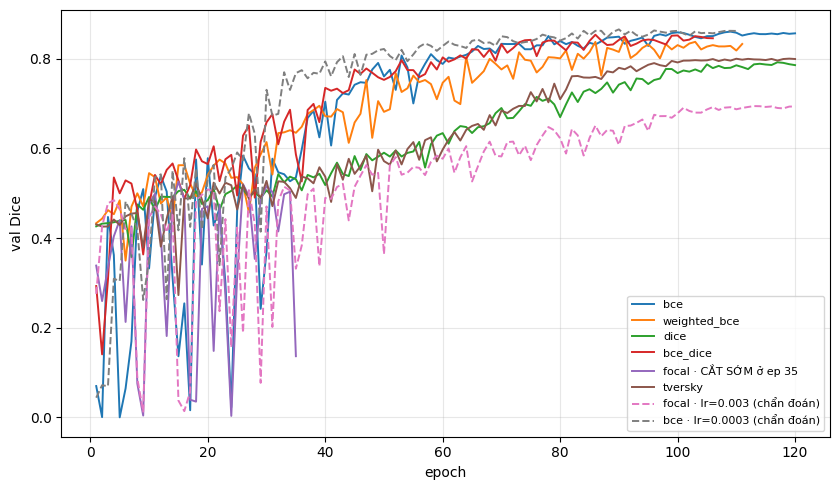

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8.5, 5))
for name, h in histories.items():
    ax.plot([x["epoch"] for x in h], [x["val_dice"] for x in h], lw=1.4, label=name)
for name, h in extra.items():
    ax.plot([x["epoch"] for x in h], [x["val_dice"] for x in h], lw=1.4,
            ls="--", label=name)
ax.set_xlabel("epoch")
ax.set_ylabel("val Dice")
ax.grid(alpha=0.3)
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
fig.savefig(f"{base.fig_dir}/loss_sweep_valdice.png", dpi=150, bbox_inches="tight")

## Câu hỏi cần trả lời trong báo cáo

1. Dice-based loss có thắng BCE không, và chênh bao nhiêu? Chênh đó có lớn
   hơn dao động giữa các seed không?
2. Weighted BCE và Focal đều nhắm vào mất cân bằng lớp — cái nào hiệu quả hơn
   ở đây, và tại sao?
3. Tversky với `beta > alpha` có làm recall tăng và precision giảm đúng như
   kỳ vọng lý thuyết không? Kiểm bằng đúng hai cột đó trong bảng.
4. Đường nào bị early stopping cắt sớm? Con số của lượt đó phản ánh một điểm
   dừng ngẫu nhiên chứ không phải giới hạn của hàm mất mát, và **phải** được
   chú thích như vậy dưới bảng.

## Lặp seed cho 3 cấu hình tốt nhất

Không bắt buộc với đề tài 5, nhưng đây là chỗ ăn điểm mục *Thí nghiệm và
phân tích*: nó cho phép nói câu "khác biệt này nằm trong nhiễu".

In [11]:
top3 = table["loss_name"].head(3).tolist()
seed_configs = [base.replace(loss_name=name, seed=1337, tag="loss_seed2")
                for name in top3]
results_seed2 = run_sweep(seed_configs)


----- [1/3] -----
=== bce_dice-transpose-full-s1337-4ba512 === 31,037,633 tham số, thiết bị cuda
epoch   1/120 | train 0.6464 | val 0.5376 | val dice 0.4427 | val iou 0.3175 *
epoch   2/120 | train 0.5629 | val 0.5354 | val dice 0.2651 | val iou 0.1729
epoch   3/120 | train 0.5315 | val 0.5165 | val dice 0.4010 | val iou 0.2765
epoch   4/120 | train 0.5085 | val 0.5108 | val dice 0.4490 | val iou 0.3163 *
epoch   5/120 | train 0.4968 | val 0.4747 | val dice 0.5139 | val iou 0.3789 *
epoch   6/120 | train 0.4907 | val 0.5290 | val dice 0.3345 | val iou 0.2302
epoch   7/120 | train 0.4860 | val 0.4527 | val dice 0.5155 | val iou 0.3779 *
epoch   8/120 | train 0.4785 | val 0.5530 | val dice 0.2599 | val iou 0.1791
epoch   9/120 | train 0.4763 | val 0.4655 | val dice 0.4838 | val iou 0.3510
epoch  10/120 | train 0.4608 | val 0.5169 | val dice 0.2949 | val iou 0.2030
epoch  11/120 | train 0.4618 | val 0.4614 | val dice 0.5068 | val iou 0.3757
epoch  12/120 | train 0.4597 | val 0.4392 | val